In [3]:
%pip install geopandas


Note: you may need to restart the kernel to use updated packages.


In [105]:
import googlemaps
import os
import pandas as pd
from dotenv import load_dotenv
from fuzzywuzzy import fuzz
import numpy as np
import regex as re
import json
import ast
import geopandas as gpd
import matplotlib
from shapely.geometry import Point
import function

In [5]:
maps_client = googlemaps.Client(key = os.getenv('google_maps_api_key'))

In [6]:
mcdonalds = maps_client.places("McDonalds, Madison")
mcdonalds = maps_client.place('ChIJs-aLQc6sB4gRFe2Zx4HReSM', fields=['reviews'])

In [7]:
mcdonalds

{'html_attributions': [],
 'result': {'reviews': [{'author_name': 'Emmanuel Fernandez',
    'author_url': 'https://www.google.com/maps/contrib/115778137543745412555/reviews',
    'language': 'en',
    'original_language': 'en',
    'profile_photo_url': 'https://lh3.googleusercontent.com/a-/ALV-UjX6IlZB7oQ3jQkNTyqQOSURtp99NVSq9gjMO6-qRDNWl4C_q7c=s128-c0x00000000-cc-rp-mo',
    'rating': 1,
    'relative_time_description': '3 months ago',
    'text': '(Drive-thru – 13 Nov 2025, ~5:30 AM)\nThe window attendant this morning was confrontational and extremely unprofessional. He said his name was Brandon, though I’m not sure that’s accurate. He’s a short Hispanic male who wears a blue button-up shirt and is usually stationed at the front counter or pick-up window.\n\nI normally give service workers the benefit of the doubt—they’re often overworked and underpaid—but this individual has been consistently rude in past visits and has also gotten my orders wrong before due to what seems like a lac

In [8]:
review = "This Taco Bell is the most disgusting place I have ever laid my eyes on. It takes an exhaustive effort to lift your feet off of the floors. I felt like a mouse stuck on a glue trap. I have been here a few times and it's always terrible. The soda machines have never been cleaned and never will be cleaned. I am not kidding when I say that you can taste the mold or whatever other nastiness is in the soda machine and nozzles. Anyone who has worked in this type of industry knows that these machines need to be cleaned every night and deep cleaned every week, if you order a soda from here you will notice that it tastes almost like burnt hair. Just so incredibly disgusting it's unbelievable really. You cannot order at the counter, but they have kiosks. I use the mobile app and consistently what happens is my food is ready just sitting there and I can see it and it always takes them several minutes to simply just hand it to me. This most recent time I waited a very long time for my food to be ready and then it sat for a couple of minutes so I went up to kindly ask the worker if my order was ready, knowing that it was, and he just did not interact with me at all. he was 2 feet in front of me and just looking down a little bit and he looked extremely high, and had large open sores on his face. I don't think someone with open sores on their face should be working around food at all. I cant believe he was allowed to work in that condition. I did not even eat my food after seeing this I just threw it away. I think I have a moral obligation to call the health department to inspect this place and shut it down."

In [9]:
fuzz.partial_ratio("tacobell", "".join(review.lower().split()))
"tacobell" in "".join(review.lower().split())

True

In [10]:
re.sub("(?i)taco\s*bell", "*****", review)

"This ***** is the most disgusting place I have ever laid my eyes on. It takes an exhaustive effort to lift your feet off of the floors. I felt like a mouse stuck on a glue trap. I have been here a few times and it's always terrible. The soda machines have never been cleaned and never will be cleaned. I am not kidding when I say that you can taste the mold or whatever other nastiness is in the soda machine and nozzles. Anyone who has worked in this type of industry knows that these machines need to be cleaned every night and deep cleaned every week, if you order a soda from here you will notice that it tastes almost like burnt hair. Just so incredibly disgusting it's unbelievable really. You cannot order at the counter, but they have kiosks. I use the mobile app and consistently what happens is my food is ready just sitting there and I can see it and it always takes them several minutes to simply just hand it to me. This most recent time I waited a very long time for my food to be read

In [11]:
review_df = pd.read_csv("testing_reviews.csv")


In [12]:
reviews_list = ast.literal_eval(review_df["reviews"][0])['reviews']

TypeError: list indices must be integers or slices, not str

In [ ]:
for review in reviews_list:
    print(review)
    

{'author_name': 'Pam Buss', 'author_url': 'https://www.google.com/maps/contrib/107829775833265139536/reviews', 'language': 'en', 'original_language': 'en', 'profile_photo_url': 'https://lh3.googleusercontent.com/a/ACg8ocIP-9GkylFlK3ZHN7Lsd2TQqboeCSSxDghC_cxCSyMcPsqvjA=s128-c0x00000000-cc-rp-mo-ba5', 'rating': 5, 'relative_time_description': 'a month ago', 'text': 'Went here with 2 others prior to a show at Overture. We had a reservation and were  immediately seated.\nThe restaurant is long and narrow with the bar taking up one side. Very nice atmosphere. We each had a speciality drink; painkiller, clover club, and proprietary knowledge.\nCheese curd appetizer which was yummy.\nEntrees included the lobster roll with truffle fries, shrimp risotto special and campanelle pasta. All our food was outstanding.\nService was excellent.\nI recommend checking this place out.', 'time': 1768070029, 'translated': False}
{'author_name': 'Shruti A', 'author_url': 'https://www.google.com/maps/contrib/1

In [ ]:
botanist = pd.DataFrame(reviews_list)

In [ ]:
botanist[(botanist['rating'] == 5) | (botanist['rating'] == 4)]

,author_name,author_url,language,original_language,profile_photo_url,rating,relative_time_description,text,time,translated
0,Pam Buss,https://www.google.com/maps/contrib/1078297758...,en,en,https://lh3.googleusercontent.com/a/ACg8ocIP-9...,5,a month ago,Went here with 2 others prior to a show at Ove...,1768070029,False
1,Shruti A,https://www.google.com/maps/contrib/1000255682...,en,en,https://lh3.googleusercontent.com/a/ACg8ocK5Cx...,5,a month ago,We really wanted to try this place and ended u...,1767727612,False
2,Kate Stephan,https://www.google.com/maps/contrib/1151953395...,en,en,https://lh3.googleusercontent.com/a-/ALV-UjXQZ...,5,a week ago,The service here is amazing. They’re so knowle...,1770513420,False
3,Karyl Kubiak,https://www.google.com/maps/contrib/1073783970...,en,en,https://lh3.googleusercontent.com/a/ACg8ocK7IY...,5,a week ago,My husband and I had a wonderful time here bef...,1770512220,False
4,Sarah K,https://www.google.com/maps/contrib/1053924132...,en,en,https://lh3.googleusercontent.com/a/ACg8ocJJBl...,5,4 months ago,Loved The Botanist Social! We were seated righ...,1759074440,False


In [ ]:
botanist[(botanist['rating'] == 1) | (botanist['rating'] == 2)]

In [ ]:
def reviews_to_dict(row):
    # print(row)
    reviews = pd.DataFrame(ast.literal_eval(row['reviews'])['reviews'])
    # print(reviews)
    return reviews.iloc[0]

review_df.apply(reviews_to_dict, axis=1)

,author_name,author_url,language,original_language,profile_photo_url,rating,relative_time_description,text,time,translated
0,Pam Buss,https://www.google.com/maps/contrib/1078297758...,en,en,https://lh3.googleusercontent.com/a/ACg8ocIP-9...,5,a month ago,Went here with 2 others prior to a show at Ove...,1768070029,False
1,Denyse Nizam,https://www.google.com/maps/contrib/1005305109...,en,en,https://lh3.googleusercontent.com/a-/ALV-UjU-V...,5,4 months ago,Very classy vibe with amazing martinis🍸and gre...,1760881180,False
2,Jerry Murphy,https://www.google.com/maps/contrib/1182817190...,en,en,https://lh3.googleusercontent.com/a/ACg8ocI8C1...,4,3 months ago,We had three pieces of pizza and soda and the ...,1763407287,False
3,Tambra Riddle,https://www.google.com/maps/contrib/1133683813...,en,en,https://lh3.googleusercontent.com/a-/ALV-UjV5p...,5,4 months ago,I was so happy to discover this new place! It ...,1759698352,False
4,Cortney Forman,https://www.google.com/maps/contrib/1063860961...,en,en,https://lh3.googleusercontent.com/a/ACg8ocIJub...,5,a week ago,"Placed my first order today through the ""goodi...",1771046624,False
5,Danica Odyssey,https://www.google.com/maps/contrib/1023361162...,en,en,https://lh3.googleusercontent.com/a-/ALV-UjVeS...,5,3 months ago,"After a chilly, but fun day in Madison, I coul...",1761420586,False
6,chad svastisalee,https://www.google.com/maps/contrib/1057183292...,en,en,https://lh3.googleusercontent.com/a-/ALV-UjWeS...,4,3 months ago,State Street Brats deals are a great way to en...,1763898156,False
7,Dave McGowan,https://www.google.com/maps/contrib/1162310295...,en,en,https://lh3.googleusercontent.com/a-/ALV-UjU5S...,5,3 months ago,"Hot spicy fried noodles, under $8 and incredib...",1762735337,False
8,Chris,https://www.google.com/maps/contrib/1027406638...,en,en,https://lh3.googleusercontent.com/a-/ALV-UjUIR...,5,4 months ago,I was led here by a coupon for a free gyro and...,1760564662,False
9,Emmanuel Martinez,https://www.google.com/maps/contrib/1001451363...,en,en,https://lh3.googleusercontent.com/a/ACg8ocKz65...,2,2 weeks ago,"Be careful if you're vegetarian, it's the seco...",1770479803,False


In [ ]:
review_df
review_df['geometry'] = ast.literal_eval(review_df['geometry'])
# gpd.points_from_xy(review_df['geometry']['lat'], review_df['geometry']['lon'])
review_df
def lat_to_col(row):
    print(ast.literal_eval(row['geometry'])['lat'])
    return row['geometry']['lat']

ValueError: malformed node or string: 0               {'lat': 43.0748792, 'lng': -89.3883548}
1               {'lat': 43.0746997, 'lng': -89.3915933}
2               {'lat': 43.0747795, 'lng': -89.3977354}
3        {'lat': 43.0751479, 'lng': -89.39616559999999}
4               {'lat': 43.0750686, 'lng': -89.3898873}
5               {'lat': 43.0746797, 'lng': -89.3926808}
6        {'lat': 43.0747739, 'lng': -89.39594439999999}
7               {'lat': 43.0749138, 'lng': -89.3908178}
8                {'lat': 43.074912, 'lng': -89.3906454}
9         {'lat': 43.074613, 'lng': -89.38687689999999}
10              {'lat': 43.0747906, 'lng': -89.3971554}
11              {'lat': 43.0747869, 'lng': -89.3963192}
12              {'lat': 43.0749174, 'lng': -89.3909724}
13              {'lat': 43.0749792, 'lng': -89.3948478}
14                {'lat': 43.074913, 'lng': -89.386999}
15              {'lat': 43.0749112, 'lng': -89.3907116}
16         {'lat': 43.07478, 'lng': -89.39507739999999}
17        

In [ ]:
review_df.apply(lat_to_col, axis=1)

43.0748792


TypeError: string indices must be integers

array([-89.41444073,  43.05803524])

In [ ]:
city_limits = gpd.read_file('City_Limit.geojson')
water = gpd.read_file("Lakes_and_Rivers.geojson").to_crs(city_limits.crs)
streets = gpd.read_file("Street_Centerlines_and_Pavement_Data.geojson").to_crs(city_limits.crs)

In [ ]:
place_coords = np.array([-89.4070977,43.0680178])

(43.048126415420334, 43.08812641542034)

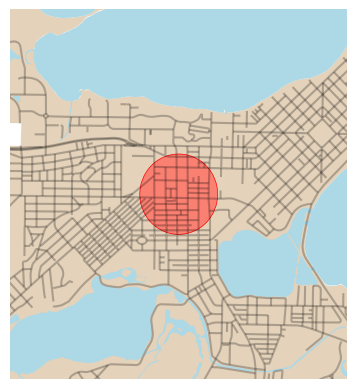

In [ ]:
rand_num = np.random.rand(2)
while np.sqrt(rand_num[0]**2 + rand_num[1]**2) > 1:
    # print('trying again')
    rand_num = rand_num = np.random.rand(2)
rand_num[0] = (rand_num[0] - 0.5) / 54.6 / 2
rand_num[1] = (rand_num[1] - 0.5) / 69 / 2
area_center = place_coords - rand_num
ax = city_limits.plot(color="tan", alpha= 0.6)
water.plot(color="lightblue", ax=ax)
streets.plot(color="black", ax=ax, alpha=0.25)
ax.set_axis_off()
# ax.plot(place_coords[0], place_coords[1], marker='o', alpha=0.5)
ax.add_patch(matplotlib.patches.Ellipse((area_center[0], area_center[1]), width = 0.6 / 52, height = 0.6 / 69,
                          edgecolor='red', facecolor='salmon', linewidth=0.5))
ax.set_xlim(area_center[0] - 0.025,
            area_center[0] + 0.025)
ax.set_ylim(area_center[1] - 0.02,
            area_center[1] + 0.02)


In [83]:
reviews_df = pd.read_csv("testing_reviews.csv")
print(reviews_df.dtypes)

Unnamed: 0           int64
name                object
place_id            object
types               object
our_type            object
our_area            object
lat                float64
long               float64
avg_rating         float64
reviews             object
url                 object
shortened_name      object
cleaned_reviews     object
dtype: object


In [ ]:
reviews

In [234]:
def choose_place(our_type, area):
    place = reviews_df.iloc[int(np.random.rand() * len(reviews_df) // 1)]
    types = ast.literal_eval(place['our_type'])
    areas = ast.literal_eval(place['our_area'])
    non_empty = ast.literal_eval(place['cleaned_reviews'])
    count = 0
    for review in ast.literal_eval(place['cleaned_reviews'])[0]:
        if type(review['text']) == str:
            count += 1
    while (not (our_type in types and area in areas)) and count < 2:
        print(place['our_type'])
        print(place['our_area'])
        place = reviews_df.iloc[int(np.random.rand() * len(reviews_df) // 1)]
        types = ast.literal_eval(place['our_type'])
        areas = ast.literal_eval(place['our_area'])
        count = 0
        for review in ast.literal_eval(place['cleaned_reviews'])[0]:
            if type(review['text']) == str:
                count += 1

    return place

In [219]:
place = choose_place('bar', 'downtown madison, wisconsin')
place

['restaurant', 'restaurant']
['downtown madison, wisconsin', 'eastside madison, wisconsin']


Unnamed: 0                                                        14
name                                              The Coopers Tavern
place_id                                 ChIJJxyDjjhTBogRoaXIlEj_rL0
types              ['bar', 'restaurant', 'food', 'point_of_intere...
our_type                         ['restaurant', 'bar', 'bar', 'bar']
our_area           ['downtown madison, wisconsin', 'downtown madi...
lat                                                        43.075083
long                                                      -89.386139
avg_rating                                                       4.5
reviews            [{'author_name': 'Tom Schweitzer', 'author_url...
url                https://maps.google.com/?cid=13667579656361518497
shortened_name                                        coopers tavern
cleaned_reviews    [[{'rating': 5, 'text': 'The food was spectacu...
Name: 14, dtype: object

In [ ]:
def get_reviews(place):
    place_reviews = ast.literal_eval(place['cleaned_reviews'])
    place_reviews_df = pd.DataFrame(place_reviews[0])
    place_reviews_df = place_reviews_df[~(place_reviews_df['text'].isna())]

    positives = place_reviews_df[place_reviews_df['rating'] == place_reviews_df.rating.max()]
    rand_positive = positives.iloc[int(np.random.rand() * len(positives))]

    negatives = place_reviews_df[place_reviews_df['rating'] == place_reviews_df.rating.min()]
    rand_negative = negatives.iloc[int(np.random.rand() * len(negatives))]

    answer = place['name']

    return {'positive': rand_positive, 'negative': rand_negative, 'answer': answer}

In [ ]:
np.array([place['long'], place['lat']])

array([ 43.0750832, -89.3861387])